#Fitting different yield curve model to US Treasuries Bond

In [26]:

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import pandas_datareader.data as pdr
import datetime as dt
import statsmodels.api as sm
import scipy as sp

In [27]:
discrete_maturities =np.array(
    [0.0833, 0.25, 0.5, 1.0, 2.0, 3.0, 5.0, 7.0, 10.0, 20.0, 30.0]
)


yields = np.array(
    [3.85, 3.92, 4.00, 4.18, 4.39, 4.46, 4.55, 4.66, 4.79, 5.27, 5.27]
)

yields = yields / 100

def factor_est(t, tau1, tau2):
    t = np.maximum(t, 1e-16)
    f0 = np.ones_like(t)
    f1 = (1 - np.exp(-t/tau1)) / (t/tau1)
    f2 = f1 - np.exp(-t/tau1)
    f3 = ((1 - np.exp(-t / tau2)) / (t / tau2)) - np.exp(-t / tau2)
    
    return np.column_stack([f0, f1, f2, f3])

tau1s = np.linspace(0.01, 4.5, 50)
tau2s = np.linspace(2.0, 50.0, 50)

best_ssr = np.inf
best_params = {}


In [28]:
for tau1 in tau1s:
    for tau2 in tau2s:
        
        if tau1 >= tau2:
            continue

        X = factor_est(discrete_maturities, tau1, tau2)

        betas, residuals, _, _ = np.linalg.lstsq(X, yields, rcond = None)

        y_pred = X @ betas
        ssr = np.sum((yields - y_pred)**2)

        if ssr < best_ssr:
            best_ssr = ssr
            best_params = {'beta0': betas[0], 'beta1': betas[1],
                'beta2': betas[2], 'beta3': betas[3],
                'tau1': tau1, 'tau2': tau2}

In [29]:
print("Best SSR:", best_ssr)
for param, value in best_params.items():
    print(f"{param}: {value:.4f}")

Best SSR: 1.641665948981183e-07
beta0: -0.0020
beta1: 0.0399
beta2: 0.0419
beta3: 0.1637
tau1: 2.1176
tau2: 16.6939


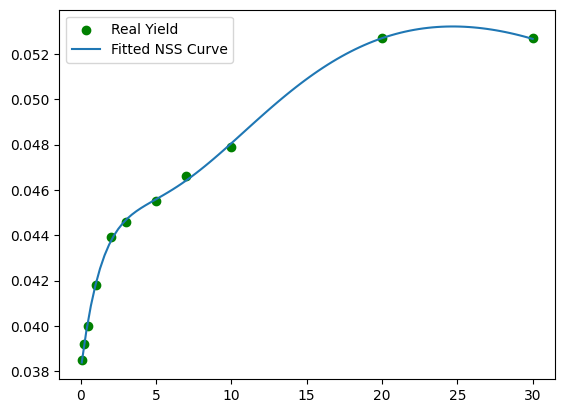

In [30]:
best_betas = np.array([
    best_params["beta0"],
    best_params["beta1"],
    best_params["beta2"],
    best_params["beta3"]
])
maturities = np.linspace(1/12, 30, 100)
fac1 = ((1 - np.exp(-maturities/best_params["tau1"])) / (maturities/best_params["tau1"]))
fac2 = (fac1 - np.exp(-maturities/best_params["tau1"]))
fac3 = (((1 - np.exp(-maturities / best_params["tau2"])) / (maturities / best_params["tau2"])) - np.exp(-maturities / best_params["tau2"]))

best_fit = best_betas[0] + best_betas[1] * fac1 + best_betas[2] * fac2 + best_betas[3] * fac3


plt.scatter(discrete_maturities, yields, color = "green", label = "Real Yield")
plt.plot(maturities, best_fit, label = "Fitted NSS Curve")
plt.legend()
plt.show()


In [31]:
comp_df = pd.DataFrame({"Real yield": yields, "Predicted Yield": y_pred})
print(comp_df)

    Real yield  Predicted Yield
0       0.0385         0.039231
1       0.0392         0.039600
2       0.0400         0.040129
3       0.0418         0.041099
4       0.0439         0.042741
5       0.0446         0.044057
6       0.0455         0.045988
7       0.0466         0.047301
8       0.0479         0.048634
9       0.0527         0.051293
10      0.0527         0.053328


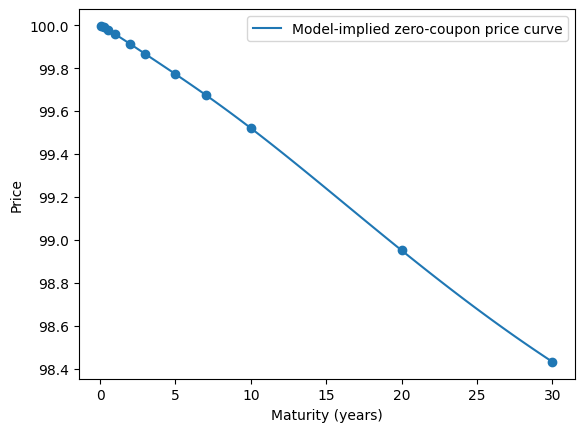

In [32]:
# Price the fitted yield curve as zero-coupon bonds
face_value = 100.0
zero_coupon_prices = face_value * np.exp(-(best_fit / 100.0) * maturities)

market_price = face_value * np.exp(-(yields / 100.0) * discrete_maturities)

plt.plot(maturities, zero_coupon_prices, label="Model-implied zero-coupon price curve")
plt.scatter(discrete_maturities, market_price)
plt.xlabel("Maturity (years)")
plt.ylabel("Price")
plt.legend()
plt.show()


In [33]:
fac1 = ((1 - np.exp(-discrete_maturities/best_params["tau1"])) / (discrete_maturities/best_params["tau1"]))
fac2 = (fac1 - np.exp(-discrete_maturities/best_params["tau1"]))
fac3 = (((1 - np.exp(-discrete_maturities / best_params["tau2"])) / (discrete_maturities / best_params["tau2"])) - np.exp(-discrete_maturities / best_params["tau2"]))

discrete_best_fit = best_betas[0] + best_betas[1] * fac1 + best_betas[2] * fac2 + best_betas[3] * fac3

discrete_modl_price = face_value * np.exp((-discrete_best_fit/100) * discrete_maturities)

price_comp_df = pd.DataFrame({"Market price": market_price, "Model price": discrete_modl_price, "Error squared": (discrete_modl_price - market_price)**2})

print(price_comp_df)

    Market price  Model price  Error squared
0      99.996793    99.996803   9.761346e-11
1      99.990200    99.990206   2.623175e-11
2      99.980002    99.979894   1.174918e-08
3      99.958209    99.958190   3.345968e-10
4      99.912239    99.912592   1.246627e-07
5      99.866289    99.866092   3.909545e-08
6      99.772759    99.772345   1.708994e-07
7      99.674331    99.675639   1.709815e-06
8      99.522145    99.520614   2.345674e-06
9      98.951535    98.951572   1.386424e-09
10     98.431432    98.432401   9.384434e-07


This part is about fitting the Diebold-Li yield curve model

In [34]:
fred_tickers = ['DGS1MO', 'DGS3MO', 'DGS6MO', 'DGS1', 'DGS2', 'DGS3', 'DGS5', 'DGS7', 'DGS10', 'DGS20', 'DGS30']
dl_discrete_mat = [1/12, 0.25, 0.5, 1, 2, 3, 5, 7, 10, 20, 30]
start = dt.datetime(2002, 1, 1)
end = dt.datetime.now()

df = pdr.DataReader(fred_tickers, 'fred', start, end)
df = (df/100).dropna()
print(df.head(-10))

            DGS1MO  DGS3MO  DGS6MO    DGS1    DGS2    DGS3    DGS5    DGS7  \
DATE                                                                         
2002-01-02  0.0173  0.0174  0.0185  0.0228  0.0322  0.0375  0.0452  0.0497   
2002-01-03  0.0173  0.0173  0.0182  0.0224  0.0319  0.0371  0.0448  0.0493   
2002-01-04  0.0172  0.0172  0.0182  0.0225  0.0319  0.0372  0.0450  0.0497   
2002-01-07  0.0170  0.0168  0.0177  0.0219  0.0308  0.0361  0.0439  0.0486   
2002-01-08  0.0170  0.0168  0.0177  0.0219  0.0307  0.0360  0.0439  0.0486   
...            ...     ...     ...     ...     ...     ...     ...     ...   
2026-08-17  0.0379  0.0387  0.0395  0.0400  0.0419  0.0425  0.0438  0.0454   
2026-08-18  0.0378  0.0386  0.0394  0.0399  0.0419  0.0426  0.0437  0.0453   
2026-08-19  0.0377  0.0386  0.0394  0.0400  0.0419  0.0425  0.0435  0.0448   
2026-08-20  0.0380  0.0387  0.0394  0.0399  0.0419  0.0426  0.0439  0.0453   
2026-08-21  0.0380  0.0388  0.0395  0.0403  0.0424  0.0431  0.04

First, fit the D-L model for the date 09/01/2026 to compare with the NSS model

In [35]:
dl_rate0901 = df.loc["2026-09-01"]
print(dl_rate0901.shape)
dl_rate0901 = np.array(dl_rate0901)

(11,)


In [36]:
dl_taugrid = np.linspace(0.01, 1.5, 100)
def dl_fac_est(mat, tau):
    mat = np.maximum(mat, 1e-16)
    fac1 = np.ones_like(mat)
    fac2 = (1 - np.exp(-mat * tau)) / (mat * tau)
    fac3 = fac2 - np.exp(-mat * tau)


    return np.column_stack([fac1, fac2, fac3])

In [37]:
dl_best_ssr = np.inf
best_dl_params = {}

for dl_tau in dl_taugrid:
    X_dl = dl_fac_est(dl_discrete_mat, dl_tau)

    dl_betas, dl_resid, _, _ = np.linalg.lstsq(X_dl, dl_rate0901, rcond = None)

    y_pred_dl = X_dl @ dl_betas
    dl_ssr = np.sum((dl_rate0901 - y_pred_dl)**2)

    if dl_ssr < dl_best_ssr:
        dl_best_ssr = dl_ssr
        best_dl_params = {'beta0': dl_betas[0], 'beta1': dl_betas[1],
                        'beta2': dl_betas[2], "tau": dl_tau}

print("Best D-L SSR:", dl_best_ssr)
for param, value in best_dl_params.items():
    print(f"{param}: {value:.4f}")

Best D-L SSR: 7.3340635985000214e-06
beta0: 0.0550
beta1: -0.0157
beta2: 0.0003
tau: 0.2358


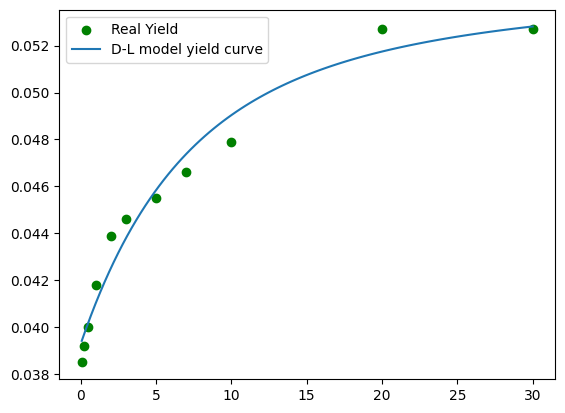

In [38]:
best_dl_betas = np.array([
    best_dl_params["beta0"],
    best_dl_params["beta1"],
    best_dl_params["beta2"]
])
best_dl_tau = best_dl_params["tau"]

dl_maturities = np.linspace(1/12, 30, 100)
dl_fac1 = (1 - np.exp(-dl_maturities * best_dl_tau)) / (dl_maturities * best_dl_tau)
dl_fac2 = dl_fac1 - np.exp(-dl_maturities * best_dl_tau)

dl_best_fit = best_dl_betas[0] + best_dl_betas[1] * dl_fac1 + best_dl_betas[2] * dl_fac2

plt.scatter(dl_discrete_mat, dl_rate0901.flatten(), color = 'green', label = "Real Yield")
plt.plot(dl_maturities, dl_best_fit, label = "D-L model yield curve")
plt.legend()
plt.show()

In [39]:
dl_yield_comp = pd.DataFrame({"Real Yield": dl_rate0901.flatten(), "Predicted Yield": y_pred_dl})
print(dl_yield_comp)

    Real Yield  Predicted Yield
0       0.0385         0.039210
1       0.0392         0.039120
2       0.0400         0.039384
3       0.0418         0.040611
4       0.0439         0.043395
5       0.0446         0.045412
6       0.0455         0.047570
7       0.0466         0.048580
8       0.0479         0.049345
9       0.0527         0.050238
10      0.0527         0.050536


NSS curve performs better in static curve-fitting. Next, we will attempt to predict yield using a AR(1) model. Instead of choosing a fix decay rate, we will calibrate it to the data

In [40]:
train_df = df[:int(len(df)*0.7)]
test_df = df[int(len(df)*0.7):]
dl_discrete_mat = np.asarray(dl_discrete_mat)
print(train_df.shape)


(4321, 11)


In [41]:
def out_ssr(params, mat, yield_df):
    lam = float(params[0])
    mat = np.asarray(mat)
    yield_df = np.asarray(yield_df)  # shape: (T, M)

    fac1 = np.ones_like(mat)
    fac2 = (1.0 - np.exp(-lam * mat)) / (lam * mat)
    fac3 = fac2 - np.exp(-lam * mat)

    X = np.column_stack([fac1, fac2, fac3])  # shape: (M, 3)

    # Solve for beta for each date: X @ beta = Y^T, with Y^T shape (M, T)
    betas, _, _, _ = np.linalg.lstsq(X, yield_df.T, rcond=None)  # shape: (3, T)

    y_pred = X @ betas  # shape: (M, T)
    ssr = np.sum((yield_df.T - y_pred) ** 2)

    return float(ssr)

x0 = [0.7308]  # Diebold-Li estimate
bounds = [(0.05, 2.0)]

result = sp.optimize.minimize(
    out_ssr,
    x0=x0, args=(dl_discrete_mat, train_df), method='L-BFGS-B', bounds=bounds)

best_is_lam = (result.x)[0]
print(best_is_lam)

0.49775035852563404


For this data, optimal in-sample lambda is not D-L chosen decay rate of 0.7308 but instead 0.4978. Now, we extract beta paramters

In [42]:
fac1 = np.ones_like(dl_discrete_mat)
fac2 = (1.0 - np.exp(-best_is_lam * dl_discrete_mat)) / (best_is_lam * dl_discrete_mat)
fac3 = fac2 - np.exp(-best_is_lam * dl_discrete_mat)
dl_des_mat = np.column_stack([fac1, fac2, fac3])
is_betas, _, _, _ = np.linalg.lstsq(dl_des_mat, train_df.T, rcond=None)

In [43]:
# Fit a separate AR(1) model to each Diebold-Li factor.
ar_results = [
    sm.tsa.AutoReg(
        is_betas[factor_idx],
        lags=1,
        trend="c",
        old_names=False,
    ).fit()
    for factor_idx in range(is_betas.shape[0])
]

for factor_idx, ar_result in enumerate(ar_results):
    print(f"AR(1) factor {factor_idx}:")
    print(ar_result.summary())


AR(1) factor 0:
                            AutoReg Model Results                             
Dep. Variable:                      y   No. Observations:                 4321
Model:                     AutoReg(1)   Log Likelihood               26104.826
Method:               Conditional MLE   S.D. of innovations              0.001
Date:                Wed, 09 Sep 2026   AIC                         -52203.652
Time:                        13:37:27   BIC                         -52184.539
Sample:                             1   HQIC                        -52196.903
                                 4321                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       6.238e-05   3.69e-05      1.690      0.091   -9.97e-06       0.000
y.L1           0.9984      0.001   1205.025      0.000       0.997       1.000
                                    

In [44]:
last_obs = is_betas.T[-1:]
print(last_obs.shape)
print(test_df.shape)

(1, 3)
(1853, 11)


In [52]:
# Recursive multi-step forecasts from each test-set origin.
forecast_horizon = 21

test_betas, _, _, _ = np.linalg.lstsq(
    dl_des_mat, test_df.to_numpy().T, rcond=None
)

n_forecasts = len(test_df) - forecast_horizon
beta_forecast = np.empty((n_forecasts, 3))

for origin in range(n_forecasts):
    previous_beta = test_betas[:, origin].copy()
    for _ in range(forecast_horizon):
        for factor_idx, ar_result in enumerate(ar_results):
            intercept, lag_coefficient = ar_result.params[:2]
            previous_beta[factor_idx] = (
                intercept + lag_coefficient * previous_beta[factor_idx]
            )
    beta_forecast[origin] = previous_beta

y_pred_test = beta_forecast @ dl_des_mat.T
forecast_actual_df = test_df.iloc[forecast_horizon:].copy()
forecast_dates = forecast_actual_df.index
print(f"{forecast_horizon}-day forecast shape:", y_pred_test.shape)


21-day forecast shape: (1832, 11)


In [53]:
error = forecast_actual_df.to_numpy() - y_pred_test
rmse = np.sqrt(np.mean(error**2))
print(f"{forecast_horizon}-day RMSE: {rmse:.6f}")


21-day RMSE: 0.002896


We will now plot a particular yield, in this case the 10-year Treasury

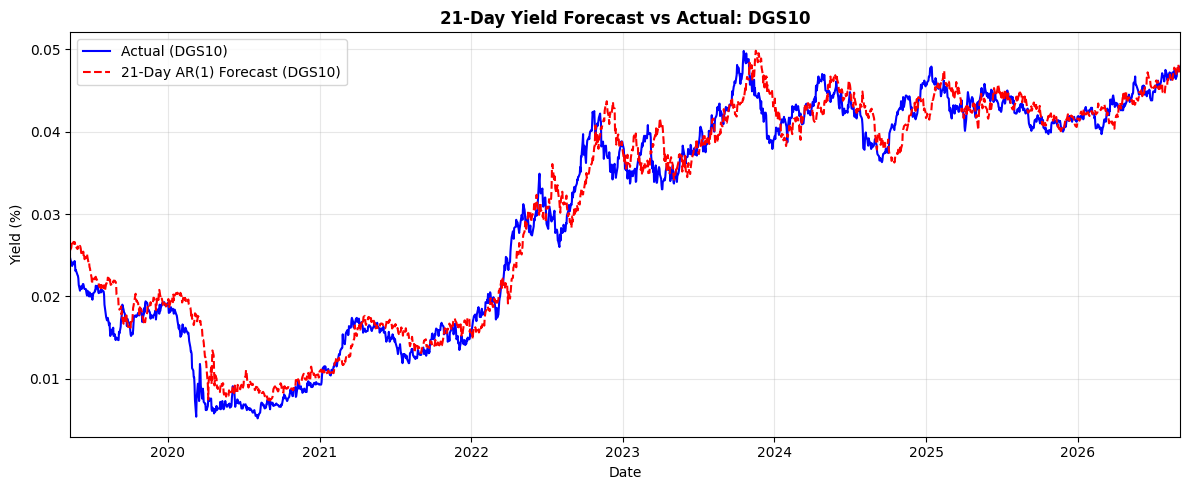

In [58]:
mat_idx = 8
actual = forecast_actual_df.iloc[:, mat_idx]
pred = y_pred_test[:, mat_idx]
label = forecast_actual_df.columns[mat_idx]

plt.figure(figsize=(12, 5))

plt.plot(forecast_dates, actual, label=f'Actual ({label})', color='blue', lw=1.5)
plt.plot(forecast_dates, pred, label=f'{forecast_horizon}-Day AR(1) Forecast ({label})', color='red', linestyle='--', lw=1.5)
plt.xlim(forecast_dates[0], forecast_dates[-1])

plt.title(f'{forecast_horizon}-Day Yield Forecast vs Actual: {label}', fontsize=12, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Yield (%)')
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()


In [55]:
# Compare the recursive multi-step AR(1) forecast with a matching random-walk forecast.
# Each forecast uses information available at its test-set origin.
random_walk_values = test_df.iloc[:-forecast_horizon].to_numpy()

actual_values = forecast_actual_df.to_numpy()
ar_values = np.asarray(y_pred_test)

# RMSE by maturity and across all maturity/date observations.
ar_rmse_by_maturity = np.sqrt(np.mean((actual_values - ar_values) ** 2, axis=0))
random_walk_rmse_by_maturity = np.sqrt(
    np.mean((actual_values - random_walk_values) ** 2, axis=0)
)

comparison = pd.DataFrame(
    {
        "AR(1) RMSE": ar_rmse_by_maturity,
        "Random Walk RMSE": random_walk_rmse_by_maturity,
    },
    index=forecast_actual_df.columns,
)

overall_ar_rmse = np.sqrt(np.mean((actual_values - ar_values) ** 2))
overall_random_walk_rmse = np.sqrt(
    np.mean((actual_values - random_walk_values) ** 2)
)

print(f"Overall {forecast_horizon}-day RMSE:")
print(f"AR(1) RMSE: {overall_ar_rmse:.6f}")
print(f"Random walk RMSE: {overall_random_walk_rmse:.6f}")
print("\nRMSE by maturity:")
print(comparison)


Overall 21-day RMSE:
AR(1) RMSE: 0.002896
Random walk RMSE: 0.002659

RMSE by maturity:
        AR(1) RMSE  Random Walk RMSE
DGS1MO    0.002464          0.003087
DGS3MO    0.002512          0.002443
DGS6MO    0.003340          0.002461
DGS1      0.003487          0.002580
DGS2      0.003180          0.002808
DGS3      0.002995          0.002825
DGS5      0.002787          0.002779
DGS7      0.002671          0.002709
DGS10     0.002640          0.002613
DGS20     0.003059          0.002467
DGS30     0.002496          0.002394
